In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
import logging
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler , MinMaxScaler, RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CLEANED_DATA_PATH="./../data/cleaned/cleaned_data.csv"
TRANSFORMATION_LOG_REPORT_PATH="./../reports/transformation_log_report.csv"
TRANSFORMATION_LOGGING_PATH="./../reports/transformation.log"

# Prepare for logging

In [3]:
logging.basicConfig(
    level=logging.INFO,
    handlers=[
        logging.FileHandler(TRANSFORMATION_LOGGING_PATH),   # writes to file
        logging.StreamHandler(),               # prints to console
    ],
)

transformation_log_Report: list[dict] = []

In [4]:
def log_transformation_action(stage: str, column: str, action: str, reason: str) -> None:
    transformation_log_Report.append({
        "stage": stage,
        "column": column,
        "action": action,
        "reason": reason,
    })
    logging.info(f"[LOG] {stage} | {column} | {action} | {reason}")

# load data

In [5]:
df = pd.read_csv(CLEANED_DATA_PATH)

In [6]:
df["price_egp"].isna().sum()

0

In [7]:
df.head()

,completion_status,price_egp,city,town,district,lat,lon,bedrooms,bathroom,area_value,...,dist_nearest_hospital_km,hospital_count_within_3km,dist_nearest_supermarket_km,supermarket_count_within_3km,dist_nearest_mall_km,mall_count_within_3km,dist_nearest_transit_station_km,transit_station_count_within_3km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_3km
0,off_plan,5145000.0,Giza,Sheikh Zayed,sheikh zayed compounds,30.048094,31.020054,2,2,123.0,...,1.813,3,1.988,3,6.410,0,8.264,0,1.451,11
1,completed,10800000.0,Cairo,New Cairo,the 5th settlement,30.012272,31.579515,4,4,250.0,...,7.118,0,7.706,0,6.502,0,7.395,0,3.353,0
2,completed,10500000.0,Cairo,New Cairo,the 5th settlement,30.026146,31.536974,2,2,136.0,...,4.022,0,4.024,0,2.407,1,3.597,0,1.225,1
3,completed,11750000.0,Giza,Sheikh Zayed,12th district,30.040565,30.990543,4,2,209.0,...,1.402,5,0.295,4,7.238,0,5.803,0,0.884,8
4,completed,2000000.0,Giza,Sheikh Zayed,sheikh zayed compounds,30.046803,31.002106,3,3,155.0,...,1.722,5,1.021,5,7.073,0,7.008,0,0.563,10


In [8]:
df.describe()

,price_egp,lat,lon,bedrooms,bathroom,area_value,dist_nearest_school_km,school_count_within_3km,dist_nearest_hospital_km,hospital_count_within_3km,dist_nearest_supermarket_km,supermarket_count_within_3km,dist_nearest_mall_km,mall_count_within_3km,dist_nearest_transit_station_km,transit_station_count_within_3km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_3km
count,2.319500e+04,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000,23195.000000
mean,7.545795e+06,29.893296,31.459127,2.587497,2.292391,150.284889,3.758248,1.601983,5.183061,1.506790,3.328091,8.334814,4.957244,0.476180,5.512321,0.429705,2.561541,10.025566
std,3.893828e+06,0.654721,0.685303,0.724162,0.766050,46.686381,3.560760,2.261124,4.797322,2.342989,3.406362,14.419009,2.840998,0.844502,2.769249,1.002973,2.587045,16.740452
min,1.131160e+05,25.069366,28.457870,1.000000,1.000000,55.000000,0.062000,0.000000,0.029000,0.000000,0.009000,0.000000,0.066000,0.000000,0.013000,0.000000,0.002000,0.000000
25%,4.650000e+06,29.987519,31.028963,2.000000,2.000000,120.500000,1.417000,0.000000,1.715000,0.000000,0.948000,0.000000,2.657000,0.000000,3.313000,0.000000,0.824000,0.000000
50%,6.600000e+06,30.034792,31.485610,3.000000,2.000000,149.000000,2.806000,1.000000,3.770000,0.000000,1.962000,2.000000,4.820000,0.000000,5.191000,0.000000,1.606000,3.000000
75%,9.689746e+06,30.069424,31.617338,3.000000,3.000000,175.000000,4.452000,2.000000,6.608000,2.000000,4.256000,7.000000,7.021000,1.000000,7.789000,0.000000,3.246000,11.000000
max,2.000000e+07,30.996363,34.896572,6.000000,6.000000,300.000000,14.343000,8.000000,18.723000,8.000000,13.205000,52.000000,11.022000,3.000000,10.378000,4.000000,10.282000,66.000000


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_histogram_with_stats(df, column_name):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True, color="skyblue", bins=50, alpha=0.5)
    plt.axvline(df[column_name].mean(), color="red", linestyle="dashed", linewidth=1, label="Mean")
    plt.axvline(df[column_name].median(), color="green", linestyle="dashed", linewidth=1, label="Median")
    plt.legend()
    plt.title('Original ' + column_name.capitalize() + ' Distribution')
    plt.xlabel(column_name.capitalize())
    plt.ylabel('Count')
    plt.show()


# define our target 


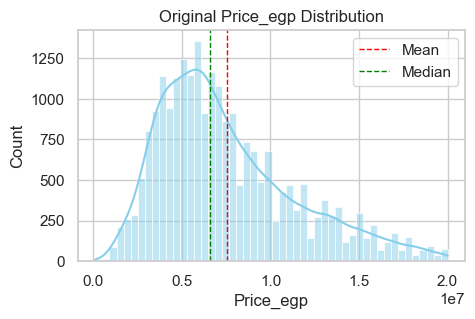

In [10]:
#split inot new col for the values of price_egp
show_histogram_with_stats(df, 'price_egp')


In [11]:
# binning the price_egp using qcut to create 3 bins (0-100, 100-200, 200+)

df['price_egp_bin'] = pd.qcut(df['price_egp'], q=3, labels=[0,1,2])

In [12]:
df['price_egp_bin'].value_counts()

price_egp_bin
1    7740
0    7732
2    7723
Name: count, dtype: int64

# Split Data into Train and Test Sets   

In [13]:
# split data into train and test sets
from sklearn.model_selection import train_test_split
X = df.drop(['price_egp', 'price_egp_bin'], axis=1)
# X = df.drop('price_category', axis=1)
y = df['price_egp_bin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)


In [14]:
# split train to train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

In [15]:
X_train_raw=X_train.copy()  
X_val_raw=X_val.copy()
X_test_raw=X_test.copy()


In [16]:
X_train=X_train_raw
X_val=X_val_raw
X_test=X_test_raw

# Feature Scaling 
-   standardization
-   Min-Max Scaling
-   Robust Scaling 

**Transform numerical features to a common scale.**

### lat, lon 
lat:
- mean 29.88
- std 0.66
- min 25
- max 30.99
- median 30.01

lon:
- mean 31.46
- std 0.69
- min 27.97
- max 34.89
- median 31.25

**will use StandardScaler**

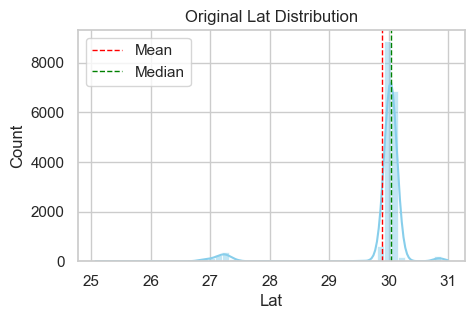

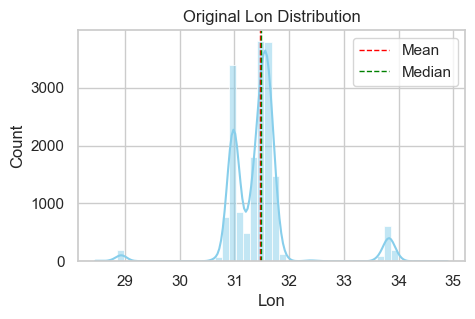

In [17]:
show_histogram_with_stats(X_train, 'lat')
show_histogram_with_stats(X_train, 'lon')

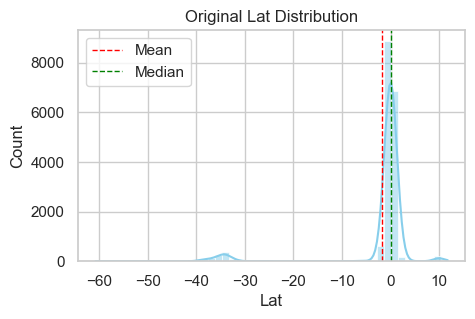

INFO:root:[LOG] Feature Scaling | lat | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


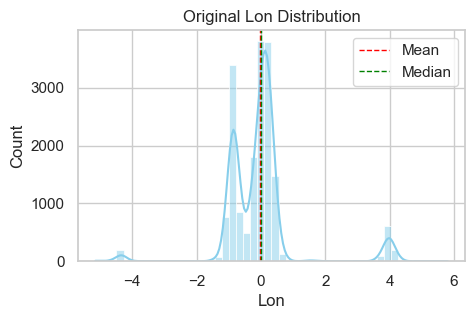

INFO:root:[LOG] Feature Scaling | lon | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


In [18]:
# apply scaling 
scaler = RobustScaler()
X_train['lat'] = scaler.fit_transform(X_train[['lat']])
X_val['lat'] = scaler.transform(X_val[['lat']])
X_test['lat'] = scaler.transform(X_test[['lat']])
show_histogram_with_stats(X_train, 'lat')
log_transformation_action(
    stage="Feature Scaling",
    column="lat",
    action="RobustScaler",
    reason="To handle outliers and scale the feature to a similar range as other features."
)



scaler = RobustScaler()
X_train['lon'] = scaler.fit_transform(X_train[['lon']])
X_val['lon'] = scaler.transform(X_val[['lon']])
X_test['lon'] = scaler.transform(X_test[['lon']])
show_histogram_with_stats(X_train, 'lon')

log_transformation_action(
    stage="Feature Scaling",
    column="lon",
    action="RobustScaler",
    reason="To handle outliers and scale the feature to a similar range as other features."     
)




###  (4) **area_value**
-   mean=145
-   median=145
-   Q1=116
-   Q3=173
-   max=765

**mean = median** <br>
**So normal distribution so will apply Standardization**

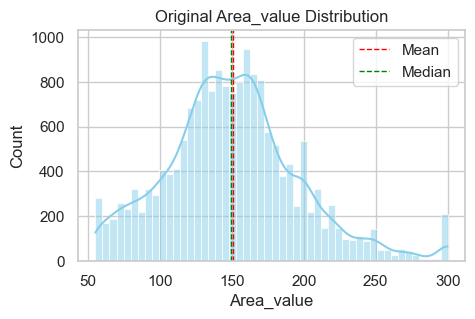

In [19]:
show_histogram_with_stats(X_train, 'area_value')


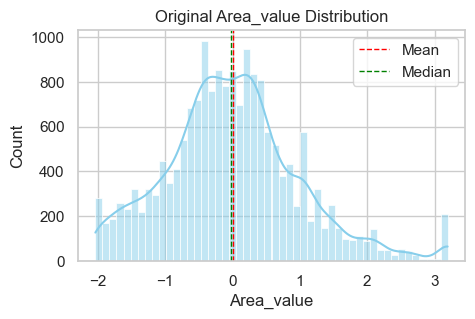

INFO:root:[LOG] Feature Scaling | area_value | StandardScaler | To scale the feature to have mean 0 and variance 1, which can help some models perform better.


In [20]:

# apply scaling 
scaler = StandardScaler()
X_train['area_value'] = scaler.fit_transform(X_train[['area_value']])
X_val['area_value'] = scaler.transform(X_val[['area_value']])
X_test['area_value'] = scaler.transform(X_test[['area_value']])
#after
show_histogram_with_stats(X_train, 'area_value')
log_transformation_action(
    stage="Feature Scaling",
    column="area_value",
    action="StandardScaler",
    reason="To scale the feature to have mean 0 and variance 1, which can help some models perform better."
)


###  (6) **distance features**
- *dist_nearest_school_km*
- *dist_nearest_hospital_km*
- *dist_nearest_supermarket_km*
- *dist_nearest_mall_km*
- *dist_nearest_transit_station_km*
- *dist_nearest_cafe_restaurant_km*

right skewed <br>
**So will apply Robust Scaling**

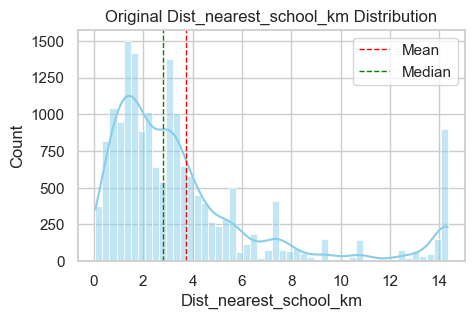

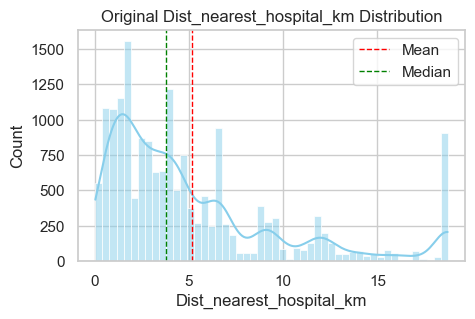

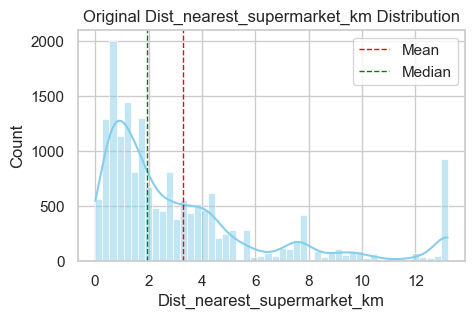

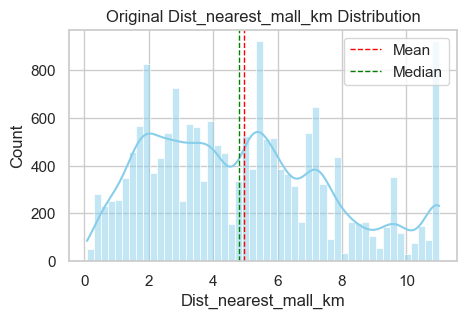

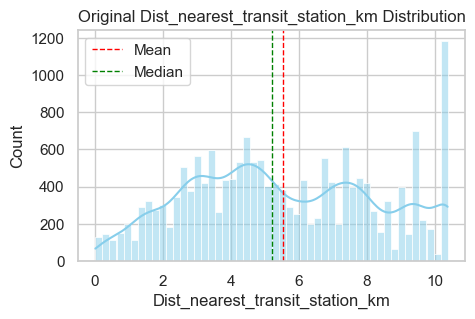

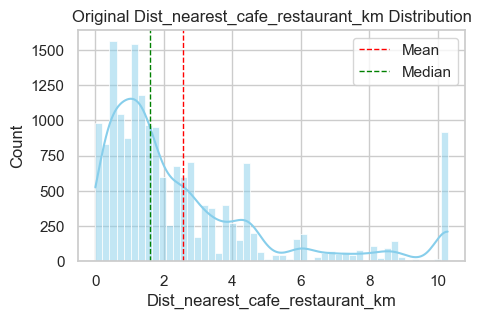

In [21]:
for col in X_train.columns:
    if col.startswith('dist_nearest'):
        show_histogram_with_stats(X_train, col)

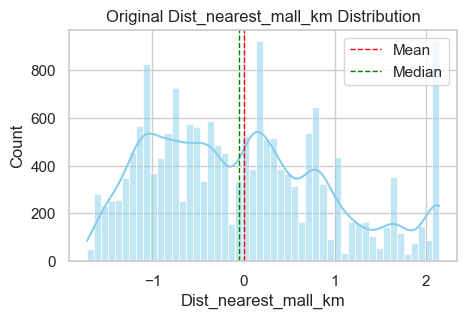

INFO:root:[LOG] Feature Scaling | dist_nearest_mall_km | StandardScaler | To scale the feature to have mean 0 and variance 1, which can help some models perform better.


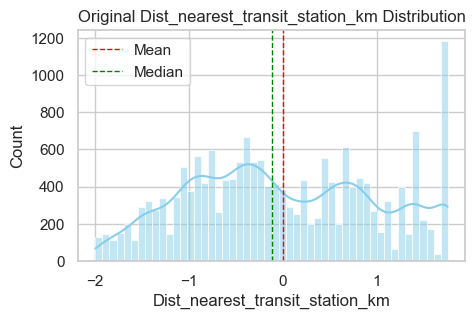

INFO:root:[LOG] Feature Scaling | dist_nearest_transit_station_km | StandardScaler | To scale the feature to have mean 0 and variance 1, which can help some models perform better.


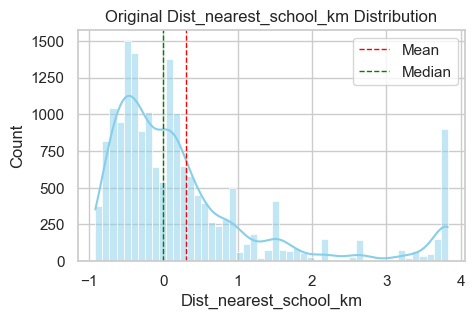

INFO:root:[LOG] Feature Scaling | dist_nearest_school_km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


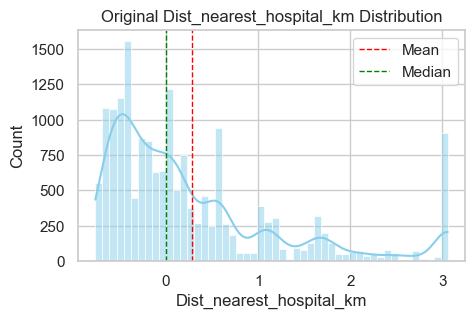

INFO:root:[LOG] Feature Scaling | dist_nearest_hospital_km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


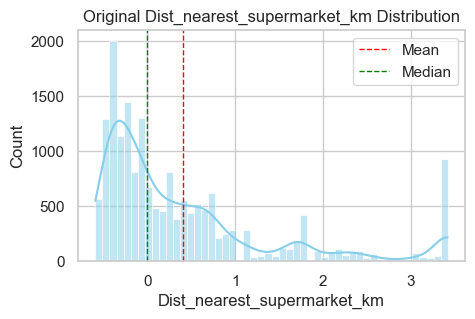

INFO:root:[LOG] Feature Scaling | dist_nearest_supermarket_km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


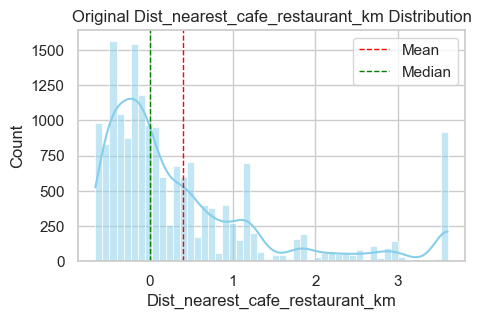

INFO:root:[LOG] Feature Scaling | dist_nearest_cafe_restaurant_km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


In [22]:
col=['dist_nearest_mall_km', 'dist_nearest_transit_station_km']

for c in col:
    scaler= StandardScaler()
    X_train[c] = scaler.fit_transform(X_train[[c]])
    X_val[c] = scaler.transform(X_val[[c]])
    X_test[c] = scaler.transform(X_test[[c]])
    show_histogram_with_stats(X_train, c)

    log_transformation_action(
        stage="Feature Scaling",
        column=c,
        action="StandardScaler",
        reason="To scale the feature to have mean 0 and variance 1, which can help some models perform better."     
    )




col =[ 'dist_nearest_school_km','dist_nearest_hospital_km', 'dist_nearest_supermarket_km','dist_nearest_cafe_restaurant_km']

for c in col:
    if c in X_train.columns:
        scaler = RobustScaler()
        X_train[c] = scaler.fit_transform(X_train[[c]])
        X_val[c] = scaler.transform(X_val[[c]])
        X_test[c] = scaler.transform(X_test[[c]])
        show_histogram_with_stats(X_train, c)
        log_transformation_action(
            stage="Feature Scaling",
            column=c,
            action="RobustScaler",
            reason="To handle outliers and scale the feature to a similar range as other features."     
        )

###  (7) **Count features**
- *school_count_within_3km*
- *hospital_count_within_3km*
- *supermarket_count_within_3km*
- *mall_count_within_3km*
- *transit_station_count_within_3km*
- *cafe_restaurant_count_within_3km*

bounded values non negative. <br>
**So will apply min-max scaling**

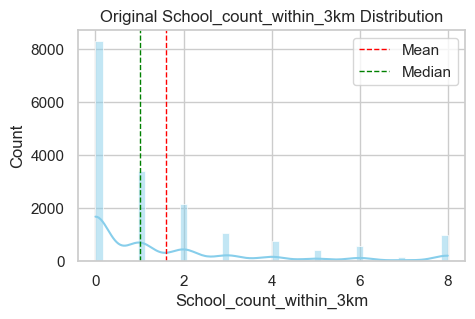

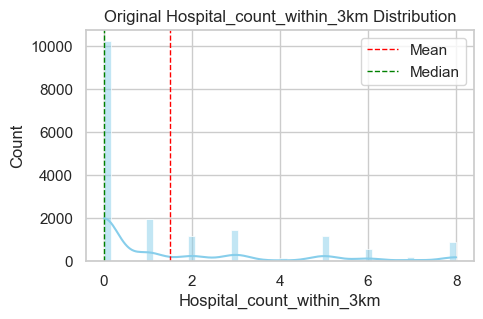

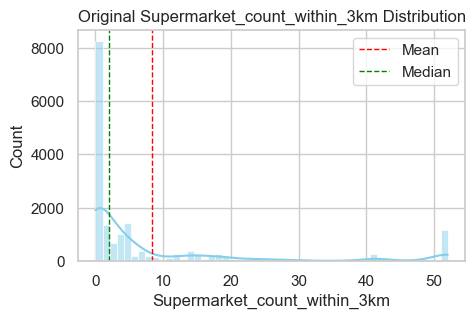

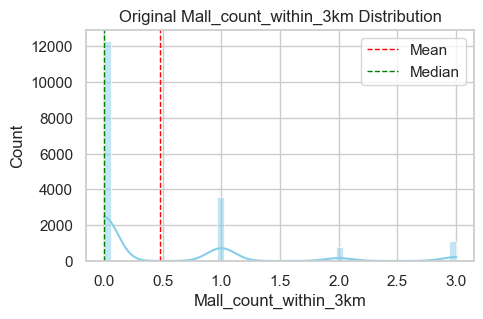

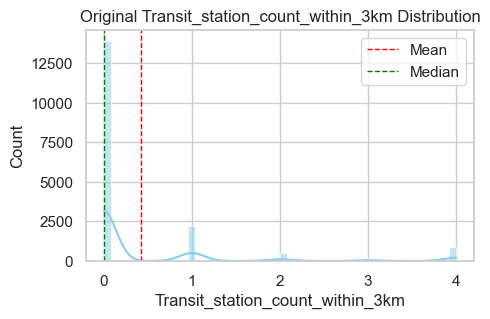

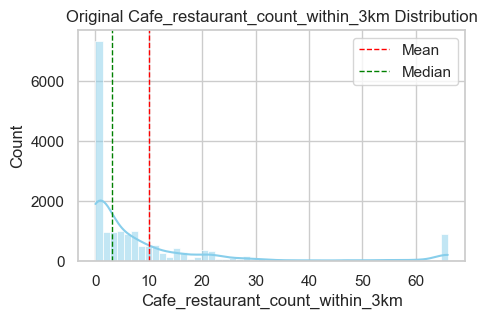

In [23]:
for col in X_train.columns:
    if col.endswith('count_within_3km'):
        show_histogram_with_stats(X_train, col)

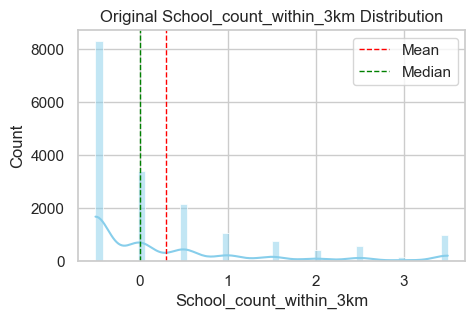

INFO:root:[LOG] Feature Scaling | school_count_within_3km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


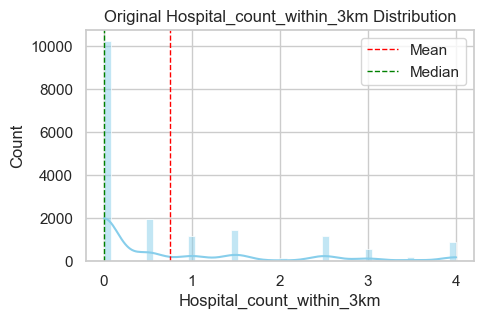

INFO:root:[LOG] Feature Scaling | hospital_count_within_3km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


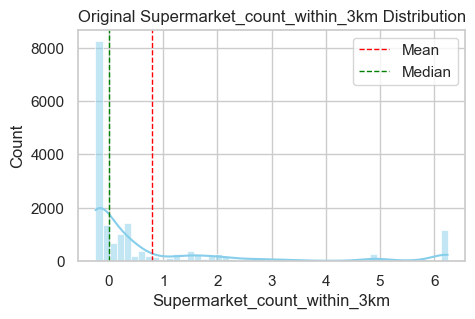

INFO:root:[LOG] Feature Scaling | supermarket_count_within_3km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


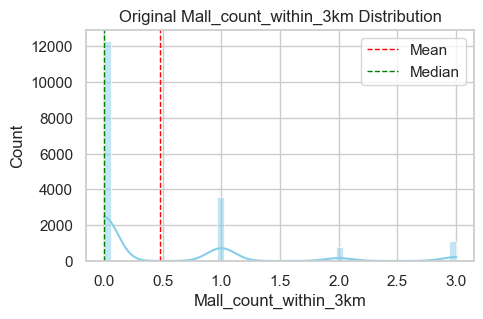

INFO:root:[LOG] Feature Scaling | mall_count_within_3km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


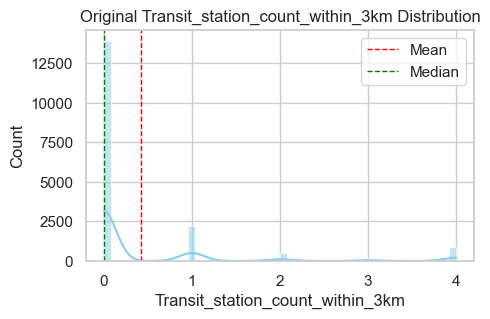

INFO:root:[LOG] Feature Scaling | transit_station_count_within_3km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


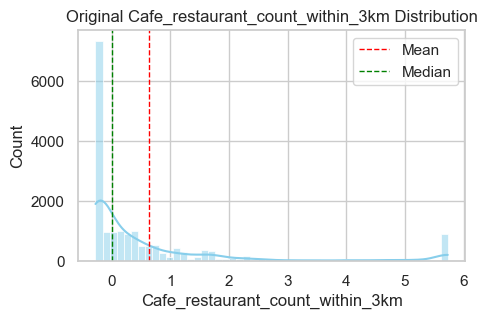

INFO:root:[LOG] Feature Scaling | cafe_restaurant_count_within_3km | RobustScaler | To handle outliers and scale the feature to a similar range as other features.


In [24]:
for col in X_train.columns:
    if col.endswith('count_within_3km'):
        scaler = RobustScaler()
        X_train[col] = scaler.fit_transform(X_train[[col]])
        X_val[col] = scaler.transform(X_val[[col]])
        X_test[col] = scaler.transform(X_test[[col]])
        show_histogram_with_stats(X_train, col)
        log_transformation_action(
            stage="Feature Scaling",
            column=col,
            action="RobustScaler",
            reason="To handle outliers and scale the feature to a similar range as other features."     
        )

In [25]:
X_train_Scaled=X_train.copy()  
X_val_Scaled=X_val.copy()
X_test_Scaled=X_test.copy()


In [26]:
X_train=X_train_Scaled
X_val=X_val_Scaled
X_test=X_test_Scaled

In [27]:
y_train.value_counts()

price_egp_bin
1    5921
0    5915
2    5907
Name: count, dtype: int64

# Feature Encoding 
-   One-Hot Encoding
-   Label Encoding
-   Target Encoding
-   Binary Encoding
-   Frequency Encoding
-   Rare Encoding

### (1) **Ordinal encode**  listing_level 
-   *standard* = 0
-  *featured* = 1
-  *premium* = 2
-  *hot* = 3
-  *superhot* = 4

as there is a clear order will apply Label Encoding

In [28]:
listing_map = {
    "standard": 0,
    "featured": 1,
    "premium": 2,
    "hot": 3,
    "superhot": 4
}

for df_ in [X_train, X_val, X_test]:
    df_["listing_level"] = df_["listing_level"].map(listing_map)


log_transformation_action(
    stage="Feature Encoding",
    column="listing_level",
    action="Ordinal Encoding",
    reason="To convert the categorical feature into a numerical format, while preserving the ordinal relationship between the categories."     
)

INFO:root:[LOG] Feature Encoding | listing_level | Ordinal Encoding | To convert the categorical feature into a numerical format, while preserving the ordinal relationship between the categories.


### (2) **completion_status**              
-   *under-construction*    
-   *off_plan*      
-   *completed*     


### (3) **furnished**
-   *Unfurnished*    
-   *Unknown*         
-   *Furnished*        
-   *PARTLY*

we will apply one-hot encoding for both completion_status and furnished as they are nominal categorical variables with no clear order.

In [29]:
cat_cols = ["completion_status", "furnished"]



encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)


encoded_train = encoder.fit_transform(X_train[cat_cols])
encoded_val = encoder.transform(X_val[cat_cols])
encoded_test = encoder.transform(X_test[cat_cols])


encoded_cols = encoder.get_feature_names_out(cat_cols)

encoded_train = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
encoded_val = pd.DataFrame(encoded_val, columns=encoded_cols, index=X_val.index)
encoded_test = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)


X_train = pd.concat([X_train.drop(columns=cat_cols), encoded_train],axis=1)

X_val = pd.concat( [X_val.drop(columns=cat_cols), encoded_val],axis=1)

X_test = pd.concat([X_test.drop(columns=cat_cols), encoded_test],axis=1)


log_transformation_action(
    stage="Feature Encoding",
    column="completion_status, furnished",
    action="One-Hot Encoding",
    reason="To convert the categorical features into a numerical format, without assuming any ordinal relationship between the categories."     
)

INFO:root:[LOG] Feature Encoding | completion_status, furnished | One-Hot Encoding | To convert the categorical features into a numerical format, without assuming any ordinal relationship between the categories.


### (4) Frequency encode 
-   *city*
-   *town*
-   *district*

In [30]:
# can make with freq of city with high price
freq_cols = ["city", "town", "district"]

for col in freq_cols:
    freq_map = X_train[col].value_counts(normalize=True)

    for df in [X_train, X_val, X_test]:
        df[col] = df[col].map(freq_map).fillna(0)

log_transformation_action(
    stage="Feature Encoding",
    column="city, town, district",
    action="Frequency Encoding",
    reason="To convert the categorical features into a numerical format, while capturing the frequency of each category which may be related to the target variable."     
)

INFO:root:[LOG] Feature Encoding | city, town, district | Frequency Encoding | To convert the categorical features into a numerical format, while capturing the frequency of each category which may be related to the target variable.


### (5) amenities convert to binary features


###  **convert bool to  int**


In [31]:
for df in [X_train, X_val, X_test]:
    bool_cols = df.select_dtypes(bool).columns
    df[bool_cols] = df[bool_cols].astype(int)

log_transformation_action(
    stage="Feature Encoding",
    column=bool_cols.tolist(),
    action="Boolean to Integer Encoding",
    reason="To convert boolean features into a numerical format "     
)

INFO:root:[LOG] Feature Encoding | ['is_premium', 'is_featured'] | Boolean to Integer Encoding | To convert boolean features into a numerical format 


In [32]:
len(X_train.columns.tolist())

28

In [33]:
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()


In [34]:
X_train=X_train_encoded
X_val=X_val_encoded
X_test=X_test_encoded

# Feature Interactions
-   Arithmetic Complications
-   Statistical Aggregations
-   Boolean and Logical Combinations


# arithmatic operations

In [35]:
def add_arithmetic_features(df):
    df = df.copy()

    df["area_per_bedroom"] = df["area_value"] / (df["bedrooms"])
    df["area_per_bathroom"] = df["area_value"] / (df["bathroom"])
    df["bathroom_per_bedroom"] = df["bathroom"] / (df["bedrooms"] )
    df["total_rooms"] = df["bathroom"] + df["bedrooms"] 

    # Counts
    count_cols = [
        "school_count_within_3km",
        "hospital_count_within_3km",
        "supermarket_count_within_3km",
        "mall_count_within_3km",
        "transit_station_count_within_3km",
        "cafe_restaurant_count_within_3km"
    ]
    df["total_services_count_3km"] = df[count_cols].sum(axis=1)

    # Distances
    dist_cols = [
        "dist_nearest_school_km",
        "dist_nearest_hospital_km",
        "dist_nearest_supermarket_km",
        "dist_nearest_mall_km",
        "dist_nearest_transit_station_km",
        "dist_nearest_cafe_restaurant_km"
    ]

    df["avg_distance_services_3km"] = df[dist_cols].mean(axis=1)
    df["min_distance_services_3km"] = df[dist_cols].min(axis=1)

    # Accessibility
    df["accessibility_score"] = sum(
        1 / (df[col] + 1) for col in dist_cols
    )

    return df

In [36]:
X_train = add_arithmetic_features(X_train)
X_val   = add_arithmetic_features(X_val)
X_test  = add_arithmetic_features(X_test)

# aggregation

In [37]:
def fit_location_stats(df):
    df = df.copy()

    district_stats = df.groupby("district").agg({
        "area_value": "mean",
        "bedrooms": "mean",
        "bathroom": "mean",
        "total_services_count_3km": "mean"
    }).rename(columns={
        "area_value": "district_avg_area",
        "bedrooms": "district_avg_bedrooms",
        "bathroom": "district_avg_bathroom",
        "total_services_count_3km": "district_avg_services"
    })

    town_stats = df.groupby("town").agg({
        "area_value": "mean",
        "bedrooms": "mean",
        "bathroom": "mean"
    }).rename(columns={
        "area_value": "town_avg_area",
        "bedrooms": "town_avg_bedrooms",
        "bathroom": "town_avg_bathroom"
    })


    global_stats = {
        "area_value": df["area_value"].mean(),
        "bedrooms": df["bedrooms"].mean(),
        "bathroom": df["bathroom"].mean(),
        "total_services_count_3km": df["total_services_count_3km"].mean()
    }

    return district_stats, town_stats, global_stats

In [38]:
def apply_location_stats(df, district_stats, town_stats, global_stats):
    df = df.copy()
    original_index = df.index
    df = df.merge(district_stats, on="district", how="left")
    df = df.merge(town_stats, on="town", how="left")
    df.index = original_index

    df["district_avg_area"] = (
        df["district_avg_area"]
        .fillna(df["town_avg_area"])
        .fillna(global_stats["area_value"])
    )

    df["district_avg_bedrooms"] = (
        df["district_avg_bedrooms"]
        .fillna(df["town_avg_bedrooms"])
        .fillna(global_stats["bedrooms"])
    )

    df["district_avg_bathroom"] = (
        df["district_avg_bathroom"]
        .fillna(df["town_avg_bathroom"])
        .fillna(global_stats["bathroom"])
    )

    df["district_avg_services"] = (df["district_avg_services"].fillna(global_stats["total_services_count_3km"]))
    df["town_avg_area"] = df["town_avg_area"].fillna(global_stats["area_value"])
    df["town_avg_bedrooms"] = df["town_avg_bedrooms"].fillna(global_stats["bedrooms"])
    df["town_avg_bathroom"] = df["town_avg_bathroom"].fillna(global_stats["bathroom"])

    # --- Relative features ---
    df["area_vs_district_avg"] = (df["area_value"] - df["district_avg_area"]) / df["district_avg_area"]
    df["bedrooms_vs_district_avg"] = (df["bedrooms"] - df["district_avg_bedrooms"]) / df["district_avg_bedrooms"]
    df["bathroom_vs_district_avg"] = (df["bathroom"] - df["district_avg_bathroom"]) / df["district_avg_bathroom"]

    return df

In [39]:
# get stats from train only
district_stats, town_stats, global_stats = fit_location_stats(X_train)

# Apply on every split
X_train = apply_location_stats(X_train, district_stats, town_stats, global_stats)
X_val   = apply_location_stats(X_val, district_stats, town_stats, global_stats)
X_test  = apply_location_stats(X_test, district_stats, town_stats, global_stats)

# boolean features

In [40]:
def apply_binary_features(df, area_median):
    df = df.copy()

    df["is_large_house"] = df["area_value"] > area_median
    df["is_small_house"] = df["area_value"] < area_median

    df["near_school"] = df["dist_nearest_school_km"] < 1
    df["near_mall"] = df["dist_nearest_mall_km"] < 2

    df["high_quality_listing"] = (df["is_premium"] == 1) | (df["is_featured"] == 1)
    

    return df

In [41]:
area_median = X_train["area_value"].median()

X_train = apply_binary_features(X_train, area_median)
X_val   = apply_binary_features(X_val, area_median)
X_test  = apply_binary_features(X_test, area_median)

In [42]:
# print(len(X_train.columns))

# Feature Selection
-   Filter Methods
-   Wrapper Methods
-   pemutation importance

### Step 1: Variance Threshold

In [43]:
selector = VarianceThreshold(threshold=0.1)

X_train_var = selector.fit_transform(X_train)

selected_features = X_train.columns[selector.get_support()]

X_train = pd.DataFrame(X_train_var, columns=selected_features, index=X_train.index)
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print("Remaining features:", len(selected_features))
print(selected_features)

log_transformation_action(  
    stage="Feature Selection",
    column=len(selected_features),
    action="Variance Thresholding",
    reason="To remove features that have very low variance, which are unlikely to contribute to model performance."     
)

INFO:root:[LOG] Feature Selection | 37 | Variance Thresholding | To remove features that have very low variance, which are unlikely to contribute to model performance.


Remaining features: 37
Index(['lat', 'lon', 'bedrooms', 'bathroom', 'area_value', 'listing_level',
       'is_premium', 'is_featured', 'dist_nearest_school_km',
       'school_count_within_3km', 'dist_nearest_hospital_km',
       'hospital_count_within_3km', 'dist_nearest_supermarket_km',
       'supermarket_count_within_3km', 'dist_nearest_mall_km',
       'mall_count_within_3km', 'dist_nearest_transit_station_km',
       'transit_station_count_within_3km', 'dist_nearest_cafe_restaurant_km',
       'cafe_restaurant_count_within_3km',
       'completion_status_under-construction', 'furnished_unfurnished',
       'area_per_bedroom', 'area_per_bathroom', 'total_rooms',
       'total_services_count_3km', 'avg_distance_services_3km',
       'min_distance_services_3km', 'accessibility_score', 'district_avg_area',
       'district_avg_services', 'town_avg_area', 'area_vs_district_avg',
       'is_large_house', 'is_small_house', 'near_school',
       'high_quality_listing'],
      dtype='obje

### Step 2: Correlation with target

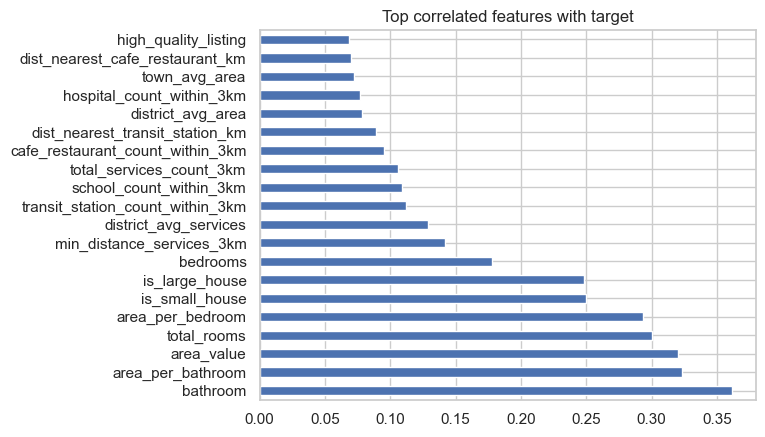

In [44]:
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
corr.head(20).plot(kind="barh")
plt.title("Top correlated features with target")
plt.show()


**Remove weak target correlation**

In [45]:
selected_corr = corr[corr > 0.005].index.tolist()
print(len(selected_corr))

X_train = X_train[selected_corr]
X_val = X_val[selected_corr]
X_test = X_test[selected_corr]

log_transformation_action(
    stage="Feature Selection",
    column=len(selected_corr),
    action="Correlation Thresholding",
    reason="To remove features that have a very low correlation with the target variable, which are unlikely to contribute to model performance."     
)


INFO:root:[LOG] Feature Selection | 37 | Correlation Thresholding | To remove features that have a very low correlation with the target variable, which are unlikely to contribute to model performance.


37


### Step 3: Remove multicollinearity

In [46]:
# Find and remove multicollinear features
def find_correlated_features(corr_matrix, threshold=0.9):
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    correlated_pairs = []
    for column in upper.columns:
        if column == 'target':
            continue
        corr_feats = upper. index[abs(upper[column]) > threshold].tolist()
        for cf in corr_feats:
            if cf != 'target':
                correlated_pairs. append({
                'feature_A': column,
                'feature_B': cf,
                'correlation': round(corr_matrix. loc[column, cf], 3),
                })

    return pd. DataFrame(correlated_pairs)

In [47]:
df_corr=X_train.copy()
df_corr["target"] = y_train
corr_matrix = df_corr.corr()
print(corr_matrix)
print("\nCorrelation with target (sorted):")
print(corr_matrix['target'].sort_values(ascending=False).round(4).to_string())

                                      bathroom  area_per_bathroom  area_value  \
bathroom                              1.000000           0.698781    0.664070   
area_per_bathroom                     0.698781           1.000000    0.907815   
area_value                            0.664070           0.907815    1.000000   
total_rooms                           0.911758           0.806203    0.776737   
area_per_bedroom                      0.658257           0.950147    0.891786   
is_small_house                       -0.570597          -0.691756   -0.767853   
is_large_house                        0.567472           0.689085    0.768214   
bedrooms                              0.642491           0.764420    0.746189   
min_distance_services_3km             0.058640          -0.062696   -0.101496   
district_avg_services                -0.066543           0.012278    0.043117   
transit_station_count_within_3km     -0.078714          -0.014051    0.021279   
school_count_within_3km     

In [48]:
correlated_features = find_correlated_features(corr_matrix, threshold=0.9)
print("\nHighly correlated feature pairs (|r| > 0.9):")
print(correlated_features.to_string(index=False))


features_to_remove = set()
for _, row in correlated_features.iterrows():
    feat1, feat2 = row['feature_A'], row['feature_B']
    corr_1_t = abs(corr_matrix.loc[feat1, 'target'])
    corr_2_t = abs(corr_matrix.loc[feat2, 'target'])
    features_to_remove.add(feat2 if corr_1_t > corr_2_t else feat1)

features_to_keep = [
    c for c in df_corr.columns if c not in features_to_remove and c != 'target'
]


Highly correlated feature pairs (|r| > 0.9):
               feature_A                 feature_B  correlation
              area_value         area_per_bathroom        0.908
             total_rooms                  bathroom        0.912
        area_per_bedroom         area_per_bathroom        0.950
          is_large_house            is_small_house       -0.988
                bedrooms               total_rooms        0.901
dist_nearest_hospital_km avg_distance_services_3km        0.914


In [49]:
print(features_to_remove)
print(features_to_keep)

{'total_rooms', 'dist_nearest_hospital_km', 'bedrooms', 'is_large_house', 'area_per_bedroom', 'area_value'}
['bathroom', 'area_per_bathroom', 'is_small_house', 'min_distance_services_3km', 'district_avg_services', 'transit_station_count_within_3km', 'school_count_within_3km', 'total_services_count_3km', 'cafe_restaurant_count_within_3km', 'dist_nearest_transit_station_km', 'district_avg_area', 'hospital_count_within_3km', 'town_avg_area', 'dist_nearest_cafe_restaurant_km', 'high_quality_listing', 'area_vs_district_avg', 'near_school', 'dist_nearest_mall_km', 'mall_count_within_3km', 'listing_level', 'furnished_unfurnished', 'dist_nearest_supermarket_km', 'is_featured', 'avg_distance_services_3km', 'lat', 'dist_nearest_school_km', 'supermarket_count_within_3km', 'lon', 'completion_status_under-construction', 'is_premium', 'accessibility_score']


In [50]:
len(features_to_keep)

31

In [51]:
X_train = X_train[features_to_keep]
X_val = X_val[features_to_keep]
X_test = X_test[features_to_keep]

log_transformation_action(
    stage="Feature Selection",
    column=len(features_to_keep),
    action="Correlation Analysis",
    reason="To remove highly correlated features while retaining the one with the strongest correlation to the target variable, thus reducing multicollinearity and improving model performance."     
)

INFO:root:[LOG] Feature Selection | 31 | Correlation Analysis | To remove highly correlated features while retaining the one with the strongest correlation to the target variable, thus reducing multicollinearity and improving model performance.


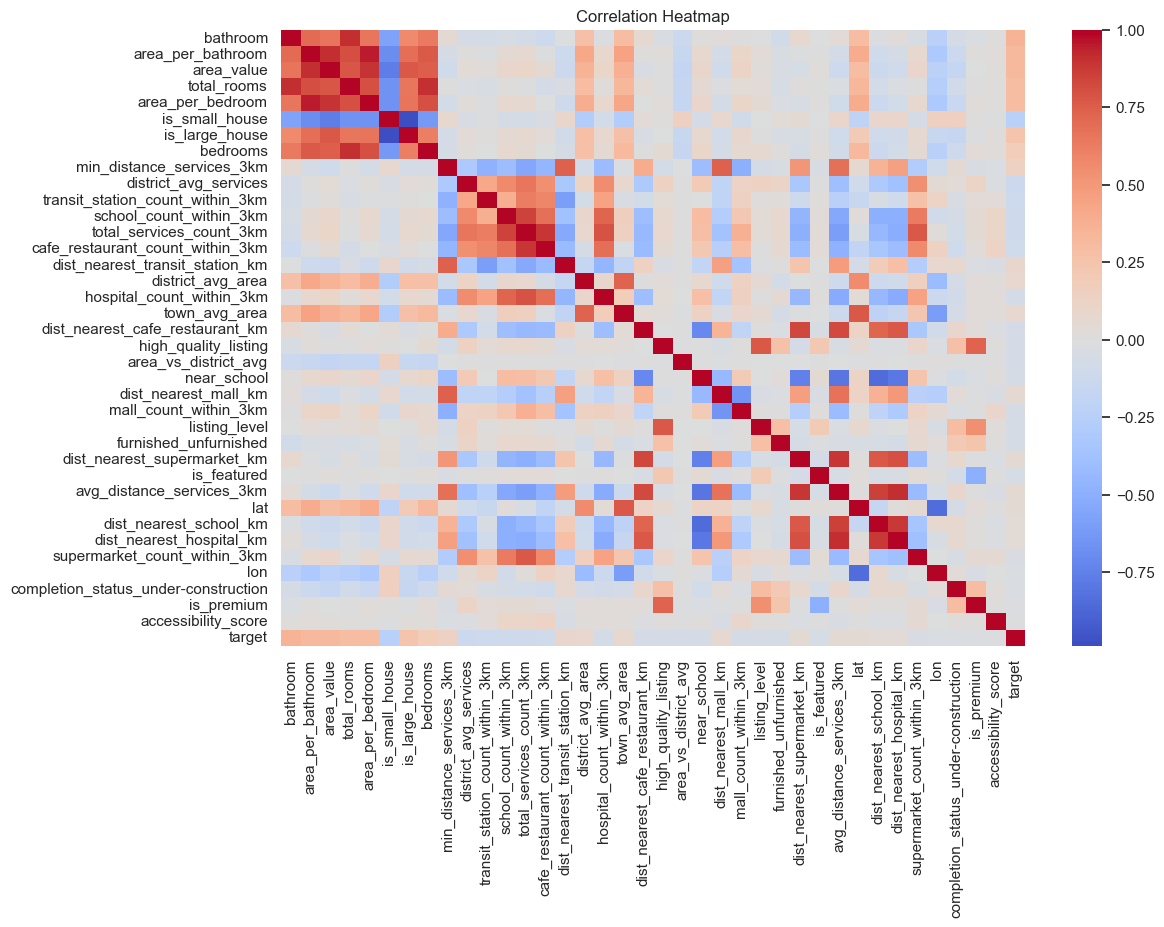

In [52]:


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()


## 2. Wrapper Method


In [53]:

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)



### RFECV

In [54]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=model,
    step=1,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,step,1
,min_features_to_select,1
,cv,5
,scoring,'neg_root_mean_squared_error'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,100
,criterion,'squared_error'
,max_depth,None


In [55]:
selected_rfecv = X_train.columns[rfecv.support_]

print("Optimal features:", len(selected_rfecv))
print(selected_rfecv)

Optimal features: 27
Index(['bathroom', 'area_per_bathroom', 'min_distance_services_3km',
       'district_avg_services', 'school_count_within_3km',
       'total_services_count_3km', 'cafe_restaurant_count_within_3km',
       'dist_nearest_transit_station_km', 'district_avg_area',
       'hospital_count_within_3km', 'town_avg_area',
       'dist_nearest_cafe_restaurant_km', 'high_quality_listing',
       'area_vs_district_avg', 'dist_nearest_mall_km', 'listing_level',
       'furnished_unfurnished', 'dist_nearest_supermarket_km', 'is_featured',
       'avg_distance_services_3km', 'lat', 'dist_nearest_school_km',
       'supermarket_count_within_3km', 'lon',
       'completion_status_under-construction', 'is_premium',
       'accessibility_score'],
      dtype='object')


In [56]:
X_train = X_train[selected_rfecv]
X_val = X_val[selected_rfecv]
X_test = X_test[selected_rfecv]

log_transformation_action(
    stage="Feature Selection",
    column=len(selected_rfecv),
    action="RFECV",
    reason="To automatically select the optimal number of features based on cross-validated model performance, while eliminating less important features."     
)

INFO:root:[LOG] Feature Selection | 27 | RFECV | To automatically select the optimal number of features based on cross-validated model performance, while eliminating less important features.


### 

In [57]:
print(y_train.isna().sum())
print(y_val.isna().sum())
print(y_test.isna().sum())

0
0
0


In [58]:
y_val.isna().sum()

0

In [59]:
print(len(y_train))
print(X_train.shape)

17743
(17743, 27)


In [60]:
print(X_train.isna().sum())
print(X_val.isna().sum())
print(X_test.isna().sum())

bathroom                                0
area_per_bathroom                       0
min_distance_services_3km               0
district_avg_services                   0
school_count_within_3km                 0
total_services_count_3km                0
cafe_restaurant_count_within_3km        0
dist_nearest_transit_station_km         0
district_avg_area                       0
hospital_count_within_3km               0
town_avg_area                           0
dist_nearest_cafe_restaurant_km         0
high_quality_listing                    0
area_vs_district_avg                    0
dist_nearest_mall_km                    0
listing_level                           0
furnished_unfurnished                   0
dist_nearest_supermarket_km             0
is_featured                             0
avg_distance_services_3km               0
lat                                     0
dist_nearest_school_km                  0
supermarket_count_within_3km            0
lon                               

In [61]:
# save transformation log report
transformation_log_df = pd.DataFrame(transformation_log_Report) 
transformation_log_df.to_csv(TRANSFORMATION_LOG_REPORT_PATH, index=False)

train_df=X_train.copy()
train_df["target"] = y_train
train_df.to_csv("./../data/processed/train.csv", index=False)

val_df=X_val.copy()
val_df["target"] = y_val
val_df.to_csv("./../data/processed/validation.csv", index=False)

test_df=X_test.copy()
test_df["target"] = y_test
test_df.to_csv("./../data/processed/test.csv", index=False)